In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve
)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load saved split data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train placement rate:", y_train.mean().round(3))
print("Test  placement rate:", y_test.mean().round(3))

ModuleNotFoundError: No module named 'xgboost'

In [3]:
import sys
print(sys.executable)

C:\Users\ACER\anaconda3\python.exe


In [4]:
import sys
import subprocess

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

import xgboost as xgb
print("Version:", xgb.__version__)

Version: 3.2.0


In [5]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve
)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load saved split data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train placement rate:", y_train.mean().round(3))
print("Test  placement rate:", y_test.mean().round(3))

Train: (4000, 22) | Test: (1000, 22)
Train placement rate: 0.86
Test  placement rate: 0.861


=== Class Distribution in Training Set ===
Placed     : 3442  (86.1%)
Not Placed : 558  (14.0%)

Imbalance ratio: 6.2:1

This imbalance will be handled using class_weight='balanced'


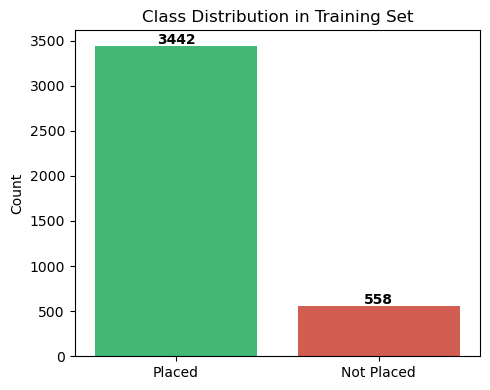

In [6]:
placed     = y_train.sum()
not_placed = len(y_train) - placed

print("=== Class Distribution in Training Set ===")
print(f"Placed     : {placed}  ({placed/len(y_train):.1%})")
print(f"Not Placed : {not_placed}  ({not_placed/len(y_train):.1%})")
print(f"\nImbalance ratio: {placed/not_placed:.1f}:1")
print("\nThis imbalance will be handled using class_weight='balanced'")

plt.figure(figsize=(5, 4))
sns.barplot(x=['Placed', 'Not Placed'],
            y=[placed, not_placed],
            palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution in Training Set')
plt.ylabel('Count')
for i, v in enumerate([placed, not_placed]):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',   # handles 86/14 imbalance
    n_jobs=-1                  # uses all CPU cores
)
rf_model.fit(X_train, y_train)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Done.")
print(f"\n{'='*40}")
print("RANDOM FOREST RESULTS")
print(f"{'='*40}")
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['Not Placed', 'Placed']))

Training Random Forest...
Done.

RANDOM FOREST RESULTS
Accuracy : 0.8930
ROC-AUC  : 0.9017

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.66      0.47      0.55       139
      Placed       0.92      0.96      0.94       861

    accuracy                           0.89      1000
   macro avg       0.79      0.72      0.75      1000
weighted avg       0.88      0.89      0.89      1000



In [8]:
print("Training XGBoost...")

# Calculate scale_pos_weight to handle imbalance for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # handles imbalance
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Done.")
print(f"\n{'='*40}")
print("XGBOOST RESULTS")
print(f"{'='*40}")
print(f"Accuracy : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred,
      target_names=['Not Placed', 'Placed']))

Training XGBoost...
scale_pos_weight: 0.162
Done.

XGBOOST RESULTS
Accuracy : 0.8530
ROC-AUC  : 0.9034

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.48      0.73      0.58       139
      Placed       0.95      0.87      0.91       861

    accuracy                           0.85      1000
   macro avg       0.72      0.80      0.75      1000
weighted avg       0.89      0.85      0.87      1000



In [9]:
rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf_proba)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)

comparison = pd.DataFrame({
    'Model'   : ['Random Forest', 'XGBoost'],
    'Accuracy': [round(rf_acc, 4),  round(xgb_acc, 4)],
    'ROC-AUC' : [round(rf_auc, 4),  round(xgb_auc, 4)]
})
print("=== Model Comparison ===")
print(comparison.to_string(index=False))

winner = 'Random Forest' if rf_auc >= xgb_auc else 'XGBoost'
print(f"\nBest model by ROC-AUC: {winner}")

=== Model Comparison ===
        Model  Accuracy  ROC-AUC
Random Forest     0.893   0.9017
      XGBoost     0.853   0.9034

Best model by ROC-AUC: XGBoost


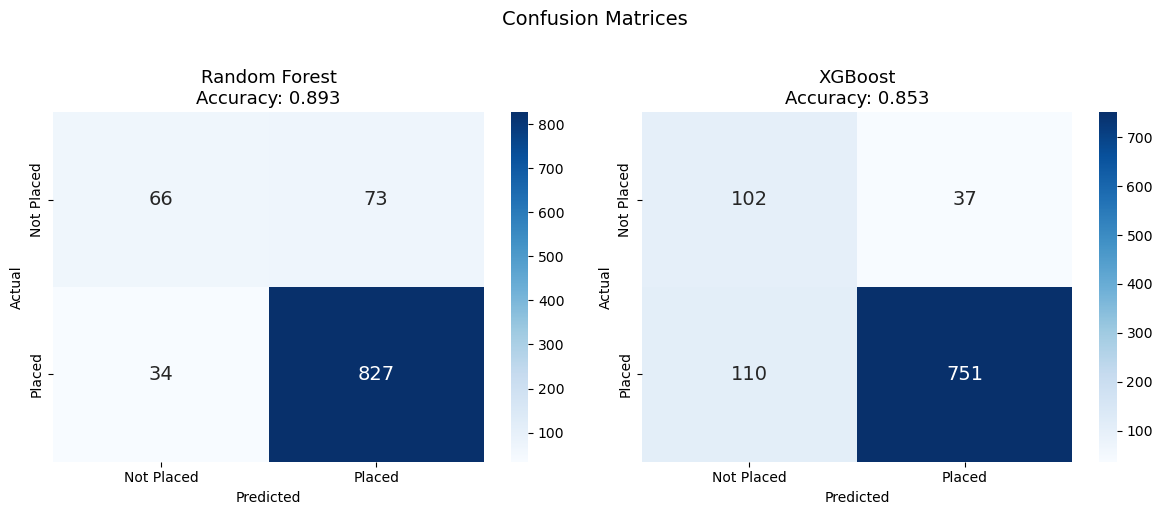

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, pred in [
    (axes[0], 'Random Forest', rf_pred),
    (axes[1], 'XGBoost',       xgb_pred)
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Placed', 'Placed'],
                yticklabels=['Not Placed', 'Placed'],
                annot_kws={'size': 14})
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.3f}',
                 fontsize=13)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/plot_confusion_matrices.png', dpi=150)
plt.show()

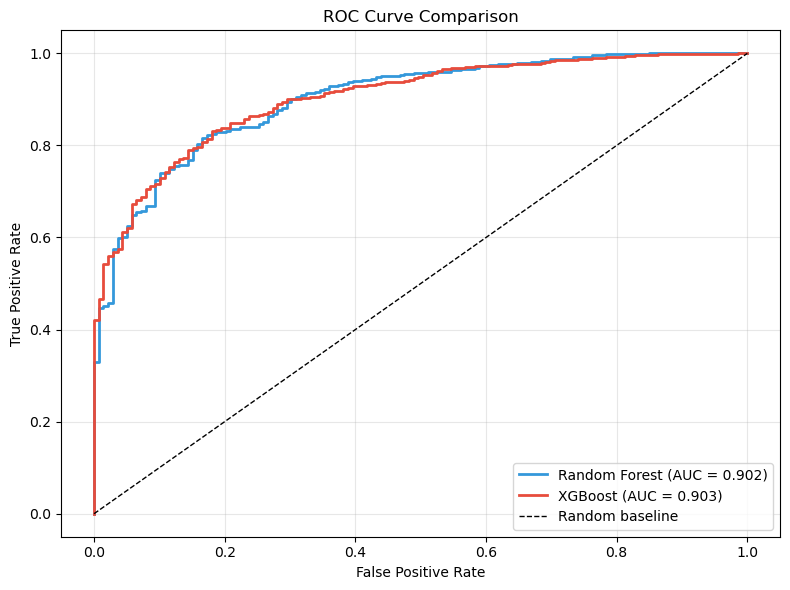

In [11]:
plt.figure(figsize=(8, 6))

for name, proba, color in [
    ('Random Forest', rf_proba,  '#3498db'),
    ('XGBoost',       xgb_proba, '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/plot_roc_curves.png', dpi=150)
plt.show()

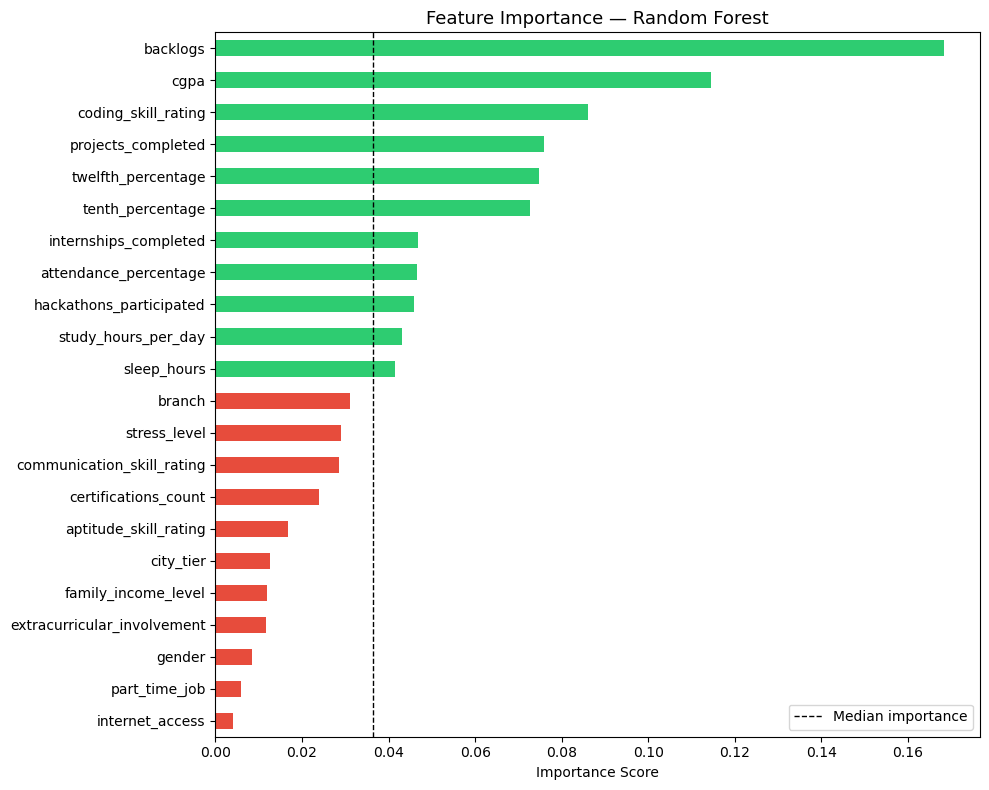


Top 5 most important features:
backlogs               0.1683
cgpa                   0.1144
coding_skill_rating    0.0862
projects_completed     0.0759
twelfth_percentage     0.0747

Bottom 5 least important features:
internet_access                0.0040
part_time_job                  0.0059
gender                         0.0084
extracurricular_involvement    0.0117
family_income_level            0.0120


In [12]:
feature_names = joblib.load('../models/feature_names.pkl')

importances = pd.Series(rf_model.feature_importances_,
                         index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if v >= importances.median()
          else '#e74c3c' for v in importances]
importances.plot(kind='barh', color=colors)
plt.axvline(importances.median(), color='black',
            linestyle='--', lw=1, label='Median importance')
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.savefig('../data/plot_feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head(5).round(4).to_string())

print("\nBottom 5 least important features:")
print(importances.sort_values(ascending=True).head(5).round(4).to_string())

In [13]:
best_model      = rf_model if rf_auc >= xgb_auc else xgb_model
best_model_name = 'Random Forest' if rf_auc >= xgb_auc else 'XGBoost'

joblib.dump(best_model, '../models/placement_model.pkl')
joblib.dump(rf_model,   '../models/rf_model.pkl')
joblib.dump(xgb_model,  '../models/xgb_model.pkl')

print(f"Best model  : {best_model_name}")
print(f"Saved to    : models/placement_model.pkl")
print(f"RF also saved  : models/rf_model.pkl")
print(f"XGB also saved : models/xgb_model.pkl")
print("\nReason: Always save both — SHAP works better with RF,")
print("so 04_explainability.ipynb will load rf_model.pkl directly.")

Best model  : XGBoost
Saved to    : models/placement_model.pkl
RF also saved  : models/rf_model.pkl
XGB also saved : models/xgb_model.pkl

Reason: Always save both — SHAP works better with RF,
so 04_explainability.ipynb will load rf_model.pkl directly.


In [14]:
print("=" * 50)
print("MODEL TRAINING COMPLETE — SUMMARY")
print("=" * 50)
print(f"Dataset        : 5000 students, 22 features")
print(f"Train/Test     : 4000 / 1000")
print(f"Class imbalance: handled via class_weight + scale_pos_weight")
print()
print(f"Random Forest  → Accuracy: {rf_acc:.4f} | ROC-AUC: {rf_auc:.4f}")
print(f"XGBoost        → Accuracy: {xgb_acc:.4f} | ROC-AUC: {xgb_auc:.4f}")
print()
print(f"Best model     : {best_model_name}")
print()
print("Saved files:")
print("  models/placement_model.pkl  ← best model")
print("  models/rf_model.pkl         ← always saved for SHAP")
print("  models/xgb_model.pkl        ← saved for reference")
print()
print("Ready for → notebooks/04_explainability.ipynb")

MODEL TRAINING COMPLETE — SUMMARY
Dataset        : 5000 students, 22 features
Train/Test     : 4000 / 1000
Class imbalance: handled via class_weight + scale_pos_weight

Random Forest  → Accuracy: 0.8930 | ROC-AUC: 0.9017
XGBoost        → Accuracy: 0.8530 | ROC-AUC: 0.9034

Best model     : XGBoost

Saved files:
  models/placement_model.pkl  ← best model
  models/rf_model.pkl         ← always saved for SHAP
  models/xgb_model.pkl        ← saved for reference

Ready for → notebooks/04_explainability.ipynb
